# 05 Random Forest Regressor zur Modellverbesserung

Author: "Zhanna Davtyan"

***Hinweis:*** Führen Sie dieses Notebook aus, nachdem Sie das `04 OLS-Modelltraining` Notebook ausgeführt haben, um die erforderlichen Metadaten zu generieren.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import scipy.stats as stats
import seaborn as sns

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [13]:
base_dir = Path.cwd()
if base_dir.name == "notebooks":
    base_dir = base_dir.parent
    os.chdir(base_dir)

### Random Forest Regressor zur Modellverbesserung

Um nicht-lineare Beziehungen und Interaktionen zwischen Features besser zu erfassen, wird ein Random Forest Regression-Modell implementiert. Random Forests als Ensemble-Methode reduzieren das Overfitting-Risiko einzelner Entscheidungsbäume durch:
- Diversifizierung mittels Datenstichproben (Bagging) 
- Zufällige Merkmalssubsets bei der Knotenteilung
- Aggregation vieler unabhängiger Bäume zu einer stabileren Vorhersage

Dies macht sie besonders robust gegenüber komplexen Datenstrukturen und Ausreißern.

Quelle: Vgl. James Gareth et al, An Introduction to Statistical Learning S. 335

In [14]:
try:
    loaded_data = pd.read_pickle('ergebnisse/modelle/ols_complete_data.pkl')
    
    X_train = loaded_data['X_train']
    X_test = loaded_data['X_test']
    y_train = loaded_data['y_train']
    y_test = loaded_data['y_test']
    X = loaded_data['X'] # Der ursprüngliche X DataFrame vor dem Splitten 
    numerical_cols = loaded_data['numerical_cols'] # Numerische Spalten
    categorical_cols = loaded_data['categorical_cols'] # Kategoriale Spalten
    
    print("Daten erfolgreich aus 'ols_train_test_data.pkl' geladen.")
    print(f"Shape von X_train: {X_train.shape}, Shape von y_train: {y_train.shape}")
    print(f"Shape von X_test: {X_test.shape}, Shape von y_test: {y_test.shape}")
    print(f"Ursprüngliche Features in X: {X.columns.tolist()}")
    print(f"Geladene numerische Spalten für RF: {numerical_cols}")
    print(f"Geladene kategoriale Spalten für RF: {categorical_cols}")
except FileNotFoundError:
    print("FEHLER: 'ols_train_test_data.pkl' nicht gefunden. Das OLS-Notebook muss zuerst ausgeführt werden und die Datei korrekt gespeichert werden.")
except KeyError as e:
    print(f"FEHLER: Ein Schlüssel wurde in der Pickle-Datei nicht gefunden: {e}")

Daten erfolgreich aus 'ols_train_test_data.pkl' geladen.
Shape von X_train: (1180, 7), Shape von y_train: (1180,)
Shape von X_test: (788, 7), Shape von y_test: (788,)
Ursprüngliche Features in X: ['follower_count', 'comment_count', 'hashtag_count', 'is_verified', 'is_professional_account', 'account_category', 'is_business_account']
Geladene numerische Spalten für RF: ['comment_count', 'follower_count', 'hashtag_count']
Geladene kategoriale Spalten für RF: ['account_category', 'is_business_account', 'is_professional_account', 'is_verified']


Für `categorical_pipeline` wird jetzt `drop=None` beim OneHotEncoder verwendet. Das behält alle Kategorien bei. Das ist für Random Forests oft besser, da sie weniger anfällig für Multikollinearität sind und so die volle Information aus den kategorialen Variablen genutzt wird.

Quelle: Vgl. James Gareth et al, An Introduction to Statistical Learning S. 346 - 347

In [15]:
numerical_pipeline = Pipeline([
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None))
])

preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
], remainder='drop')

### Definition der Evaluierungs- und Plotfunktionen

In [16]:
def regressionSummary(y_true, y_pred):
    """ Gibt die wichtigsten Regressionsmetriken aus. """
    print('\nRegressionskennzahlen (basierend auf übergebenen Daten):\n')
    metrics = [
        ('Mean Squared Error (MSE)', mean_squared_error(y_true, y_pred)),
        ('Root Mean Squared Error (RMSE)', np.sqrt(mean_squared_error(y_true, y_pred))),
        ('Mean Absolute Error (MAE)', mean_absolute_error(y_true, y_pred)),
        ('R-squared (R2)', r2_score(y_true, y_pred))
    ]
    maxlength = max(len(m[0]) for m in metrics)
    fmt1 = f'{{:<{maxlength}}} : {{:.4f}}'
    for metric, value in metrics:
        print(fmt1.format(metric, value))
    
def plot_actual_vs_predicted_rf(y_true, y_pred, model_name="Random Forest"):
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred
    target_name = y_true.name if hasattr(y_true, 'name') else 'Zielvariable'
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true_np, y_pred_np, alpha=0.5, edgecolors='k', s=50, label='Vorhersagen')
    min_val = min(y_true_np.min(), y_pred_np.min()) if (len(y_true_np) > 0 and len(y_pred_np) > 0) else 0
    max_val = max(y_true_np.max(), y_pred_np.max()) if (len(y_true_np) > 0 and len(y_pred_np) > 0) else 1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')
    plt.xlabel(f'Tatsächliche {target_name}')
    plt.ylabel(f'Vorhergesagte {target_name}')
    plt.title(f'Tatsächlich vs. Vorhergesagt - {model_name} (Testdaten)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_residuals_rf(y_true, y_pred, model_name="Random Forest"):
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred
    residuals = y_true_np - y_pred_np
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_pred_np, y=residuals, alpha=0.5, edgecolors='k', s=50)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Vorhergesagte Werte')
    plt.ylabel('Residuen (Tatsächlich - Vorhergesagt)')
    plt.title(f'Residuenplot - {model_name}')
    plt.grid(True)
    plt.show()

def plot_residuals_qq_rf(y_true, y_pred, alpha=0.5):
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred
    residuals = y_true_np - y_pred_np

    plt.figure(figsize=(8,6))
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm", plot=None)
    plt.scatter(osm, osr, alpha=alpha, edgecolor='k', s=40)
    plt.plot(osm, slope*osm + intercept, 'r-', lw=2)
    plt.title('Q-Q Plot der Residuen (Random Forest)')
    plt.xlabel('Theoretische Quantile')
    plt.ylabel('Residuen-Quantile')
    plt.grid(True)
    plt.show()

### Hyperparameter-Optimierung mit GridSearchCV für Random Forest
Ein einzelner Entscheidungsbaum neigt zum Overfitting. Random Forests, als Ensemble-Methode, reduzieren dieses Risiko durch Diversifizierung, z.B. durch Datenstichproben (Bagging) und Merkmalssubsets. Um die besten Hyperparameter für den Random Forest Regressor zu finden und die Modellleistung zu optimieren, wird GridSearchCV (Gittersuche) verwendet. 

Die Parameterwahl für das Random Forest-Modell wurde speziell auf den vorliegenden Instagram-Datensatz (1968 Zeilen, 7 Spalten) abgestimmt und basiert auf statistischen Grundprinzipien sowie wissenschaftlichen Best Practices im Machine Learning.

Quelle: Vgl. James Gareth et al, An Introduction to Statistical Learning, Tree-Based Methods.

In [ ]:
# Pipeline für Random Forest inklusive Preprocessing
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))# Alle CPU-Kerne nutzen
])

# Definition des Parameter-Gitters für GridSearchCV
param_grid_rf = {
    'regressor__n_estimators': [100, 200],              # Anzahl der Bäume im Forest
    'regressor__max_depth': [10, 20, None],             # Maximale Tiefe der Bäume 
    'regressor__min_samples_split': [10, 20, 40],       # Minimale Anzahl Samples für einen Split 
    'regressor__min_samples_leaf': [5, 10, 20],         # Minimale Anzahl Samples in einem Blattknoten
    'regressor__max_features': ['sqrt', 'log2', None]   # Anzahl Features für besten Split
}

print("GridSearchCV für Random Forest...")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3,
                              scoring='r2', n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

print(f"\nBeste gefundene Parameter für Random Forest: {grid_search_rf.best_params_}")
print(f"\nBester mittlerer R²-Wert (Cross-Validation) auf Trainingsdaten: {grid_search_rf.best_score_:.4f}")

# Das beste Modell aus GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

Starte GridSearchCV für Random Forest...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Beste gefundene Parameter für Random Forest: {'regressor__max_depth': 20, 'regressor__max_features': None, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}

Bester mittlerer R²-Wert (Cross-Validation) auf Trainingsdaten: 0.8456


#### Ergebnisse der Hyperparameter-Optimierung:

- 486 einzelne Modelltrainings wurden durchgeführt.
- Der Random Forest erklärt ~84,6% der Varianz in den Like-Zahlen.
- Die Ergebnisse sind eine deutliche Verbesserung gegenüber denen des OLS-Modells (66,7%).
- Dieser Wert stammt aus der Kreuzvalidierung und ist daher zuverlässiger als ein einzelner Train-Test-Split.

### Evaluierung des optimierten Random Forest Modells

Evaluation des optimierten Random Forest Modells auf den separaten Testdaten. Dies gibt uns eine Einschätzung, wie gut das Modell auf ungesehenen Daten generalisiert.

In [18]:
print("\nModellevaluierung für Random Forest (Testdaten)...")

y_pred_test_rf = best_rf_model.predict(X_test)

# Regressionskennzahlen
print("\n--- Random Forest: Metriken auf Testdaten (log-transformierte Likes) ---")
regressionSummary(y_test, y_pred_test_rf)


Modellevaluierung für Random Forest (Testdaten)...

--- Random Forest: Metriken auf Testdaten (log-transformierte Likes) ---

Regressionskennzahlen (basierend auf übergebenen Daten):

Mean Squared Error (MSE)       : 1.6747
Root Mean Squared Error (RMSE) : 1.2941
Mean Absolute Error (MAE)      : 0.7193
R-squared (R2)                 : 0.8594



--- Random Forest: Diagnostische Plots (Testdaten) ---


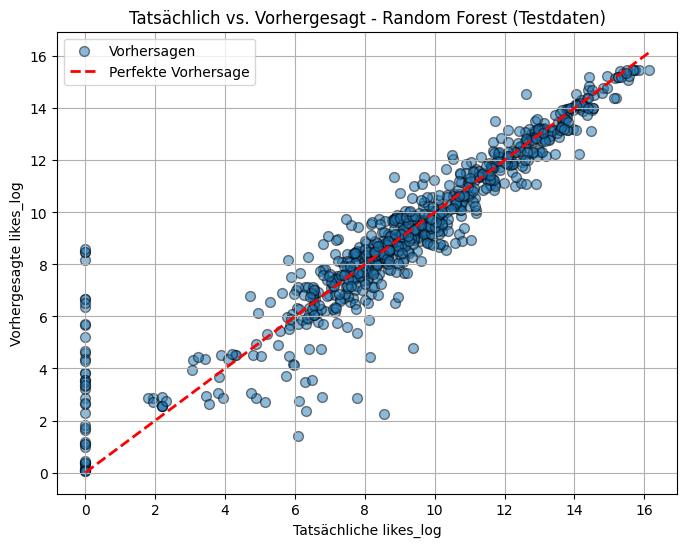

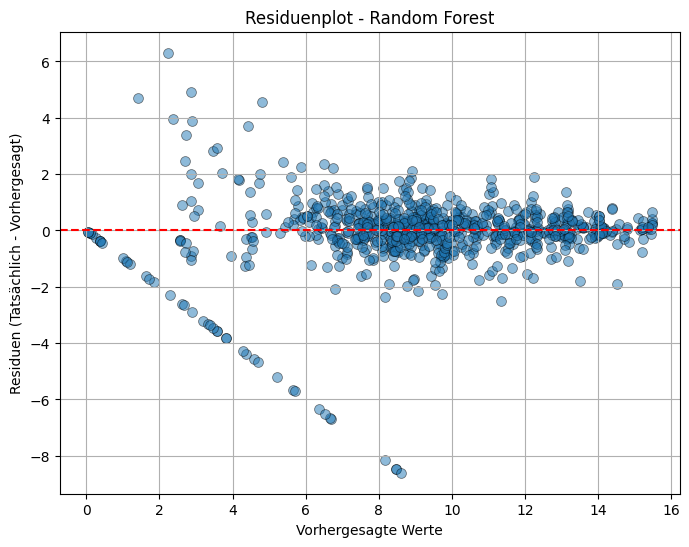

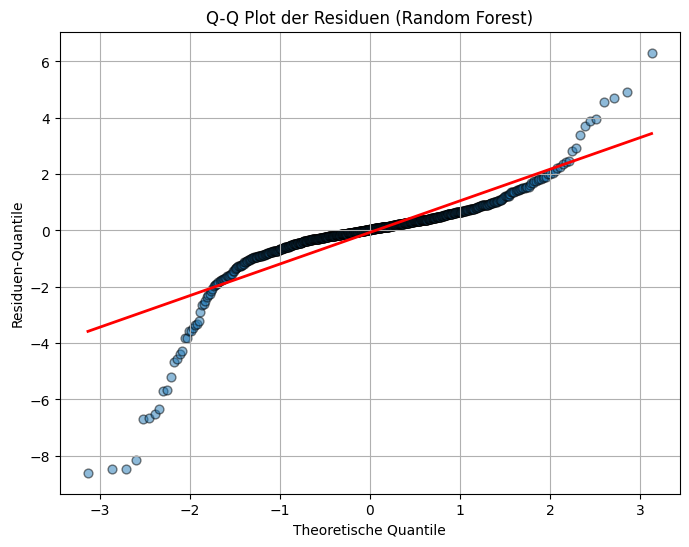

In [19]:
# die diagnostischen Plots
print("\n--- Random Forest: Diagnostische Plots (Testdaten) ---")
plot_actual_vs_predicted_rf(y_test, y_pred_test_rf, model_name="Random Forest")
plot_residuals_rf(y_test, y_pred_test_rf, model_name="Random Forest")
plot_residuals_qq_rf(y_test, y_pred_test_rf)

#### Interpretation der Evaluierungsergebnisse

- **Modellgüte**: Mit R²=0.8594 auf Testdaten erklärt das Modell ~86% der Varianz in der log-transformierten Like-Anzahl; eine erhebliche Verbesserung gegenüber dem OLS-Modell (R²≈0.65).

- **Vorhersagegenauigkeit**: Die Scatter-Plots zeigen eine deutlich bessere Anpassung an die Diagonale der perfekten Vorhersage als beim OLS-Modell, mit moderater verbleibender Streuung bei extremen Like-Zahlen.

- **Residuenanalyse**: Trotz der signifikanten Verbesserung zeigt sich ein diagonales Muster mit negativen Residuen im unteren Bereich, was auf nicht vollständig erfasste komplexe Zusammenhänge bei niedrigen Like-Zahlen hindeutet. Diese Abweichung ist bei Random Forest-Modellen weniger problematisch, da keine Normalverteilungsannahme erforderlich ist.

### Feature Importances des Random Forest Modells

Random Forests ermöglichen eine implizite Gewichtung der Attribute. Die Features werden extrahiert und die Relevanz des optimierten Modells visualisiert, um zu verstehen, welche Merkmale den größten Einfluss auf die Vorhersagen haben.

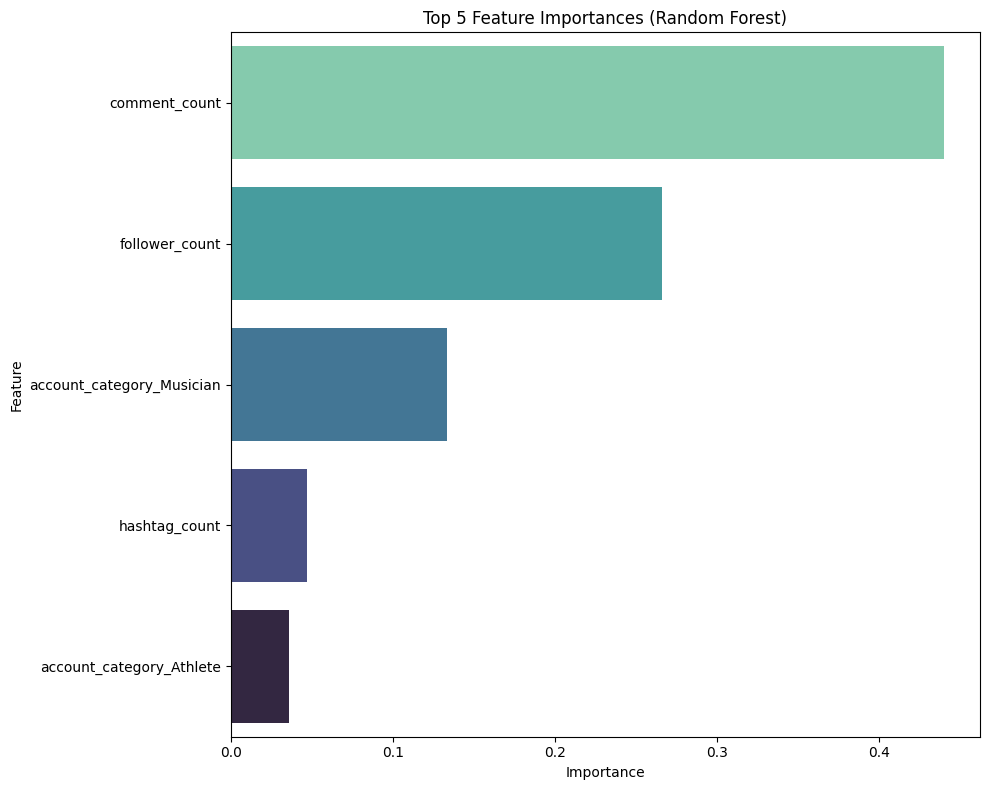

In [20]:
try:
    rf_regressor = best_rf_model.named_steps['regressor']
    preprocessor_fitted = best_rf_model.named_steps['preprocessor']

    transformed_feature = []
    
    # Numerische Features 
    if 'numerical_cols' in globals() and numerical_cols and preprocessor_fitted.named_transformers_.get('numerical'):
        transformed_feature.extend(numerical_cols)

    # One-Hot-kodierte Features 
    if 'categorical_cols' in globals() and categorical_cols and preprocessor_fitted.named_transformers_.get('categorical'):
        cat_pipeline_plot = preprocessor_fitted.named_transformers_['categorical']
        onehot_step_plot = cat_pipeline_plot.named_steps.get('onehot')
        if onehot_step_plot and hasattr(onehot_step_plot, 'get_feature_names_out'):
            onehot_feature_names_plot = onehot_step_plot.get_feature_names_out(categorical_cols)
            transformed_feature.extend(list(onehot_feature_names_plot))
        elif categorical_cols:
                print("WARNUNG: get_feature_names_out nicht verfügbar/erfolgreich für OHE im RF Plot.")
    
    if transformed_feature and hasattr(rf_regressor, 'feature_importances_') and \
        len(transformed_feature) == len(rf_regressor.feature_importances_):
        importances_rf_new = rf_regressor.feature_importances_
        feature_importance_rf_df_new = pd.DataFrame({'Feature': transformed_feature, 'Importance': importances_rf_new})
        feature_importance_rf_df_new = feature_importance_rf_df_new.sort_values(by='Importance', ascending=False).head(5)

        plt.figure(figsize=(10, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_rf_df_new, hue='Feature', palette='mako_r')
        plt.title('Top 5 Feature Importances (Random Forest)')
        plt.tight_layout()
        plt.show()
    else:
        print("Keine Feature Importances für RF verfügbar oder Feature-Namen konnten nicht extrahiert werden.")
except Exception as e:
    print(f"Fehler beim Plotten der RF Feature Importances: {e}")

### Interpretation 

- **comment_count**: Der stärkste Prädiktor, deutlich vor allen anderen Features; ein Hinweis auf die enge bidirektionale Beziehung zwischen Kommentar- und Like-Engagement.
- **follower_count**: Der zweitwichtigste Faktor, bestätigt die grundlegende Bedeutung der Reichweite für Engagement-Metriken.
- **Spezifische Account-Kategorien**: Insbesondere Musiker-Accounts weisen eine überdurchschnittlich hohe Vorhersagekraft auf, was die Relevanz der Content-Nische unterstreicht.
- **hashtag_count**: Bleibt signifikant, zeigt jedoch komplexere Zusammenhänge als im linearen OLS-Modell erfasst.

### Random Forest Modell als Pickle-Datei speichern

In [21]:
print("Das optimierte Random Forest Modell...")

model_data = {
    'model': best_rf_model,
    'best_params': grid_search_rf.best_params_,
    'feature_names': {
        'numerical_cols': numerical_cols,
        'categorical_cols': categorical_cols
    },
    'model_metrics': {
        'r2_cv': grid_search_rf.best_score_,
        'r2_test': r2_score(y_test, y_pred_test_rf),
        'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test_rf)),
        'mae_test': mean_absolute_error(y_test, y_pred_test_rf)
    }
}

with open('ergebnisse/modelle/random_forest_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Modell erfolgreich als 'random_forest_model.pkl' gespeichert.")
print("Gespeicherte Metadaten: Modell, beste Parameter, Feature-Namen und Modellgüte-Metriken.")

Das optimierte Random Forest Modell...
Modell erfolgreich als 'random_forest_model.pkl' gespeichert.
Gespeicherte Metadaten: Modell, beste Parameter, Feature-Namen und Modellgüte-Metriken.


## Fazit: Modellleistung und Implikationen

### Vorteile des Random Forest-Ansatzes
- **Überlegene Vorhersagegenauigkeit**: Mit R²≈0.86 (gegenüber OLS mit R²≈0.65) wird die deutlich bessere Erfassung komplexer Beziehungen bestätigt.
- **Robustheit**: Es sind keine strengen Verteilungsannahmen erforderlich, was bei den beobachteten nicht-normalverteilten Residuen vorteilhaft ist.
- **Automatische Modellierung**: Nicht-Linearitäten und Feature-Interaktionen werden ohne explizite Spezifikation erfasst.

| Metrik       | OLS-Modell | Random Forest | Verbesserung |
|--------------|------------|---------------|--------------|
| R²           | 0.667      | 0.859         | +0.192       |


### Limitationen
- **Interpretierbarkeit**: Trotz Feature Importance-Analyse bleibt der Random Forest eine relative "Black Box". Das bedeutet, dass die genaue Form der erfassten Zusammenhänge und Interaktionen ist weniger transparent als bei linearen Koeffizienten.

### Schlussfolgerung
Der Random Forest erweist sich als deutlich leistungsfähigeres Instrument zur Like-Vorhersage, was dessen Einsatz in Anwendungsszenarien rechtfertigt, in denen Vorhersagepräzision wichtiger ist als vollständige Modellinterpretierbarkeit.